<a href="https://colab.research.google.com/github/xanuragx-0/wind-power-prediction/blob/main/Stacked_LSTM_2Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import scipy
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import  Sequential,layers, callbacks
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from math import sqrt
from numpy import concatenate
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

from pandas.plotting import register_matplotlib_converters
import seaborn as sns

from datetime import datetime
from sklearn.metrics import mean_squared_error

%matplotlib inline

### **32-32**

Dimension of train data:  (35371, 3)
Dimension of test data:  (15159, 3)
(35371, 2)
(35371, 1)
(15159, 2)
(15159, 1)
X_train.shape:  (35362, 10, 2)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 2)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 32)            4480      
_________________________________________________________________
dropout (Dropout)            (None, 10, 32)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 32)                8320      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense (Dense)                (None, 1)                 33        
Total params: 12,833
Tr

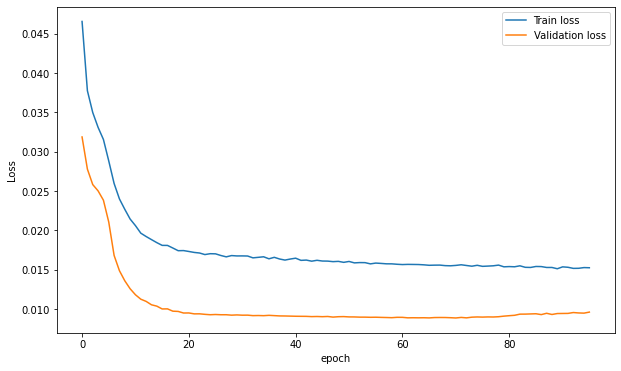

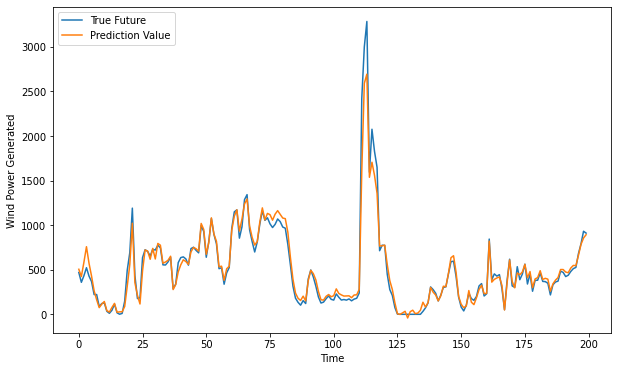

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(123)
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)
df.drop(['Theoretical_Power_Curve (KWh)'], axis=1,inplace=True)
# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 32, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  model.add(m (units = 32))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #validation_data=(X_test,y_test)
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model

# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)
#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)

def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)
# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM')

### **32-16**

Dimension of train data:  (35371, 4)
Dimension of test data:  (15159, 4)
(35371, 3)
(35371, 1)
(15159, 3)
(15159, 1)
X_train.shape:  (35362, 10, 3)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 3)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 32)            4608      
_________________________________________________________________
dropout (Dropout)            (None, 10, 32)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 16)                3136      
_________________________________________________________________
dropout_1 (Dropout)          (None, 16)                0         
_________________________________________________________________
dense (Dense)                (None, 1)                 17        
Total params: 7,761
Tra

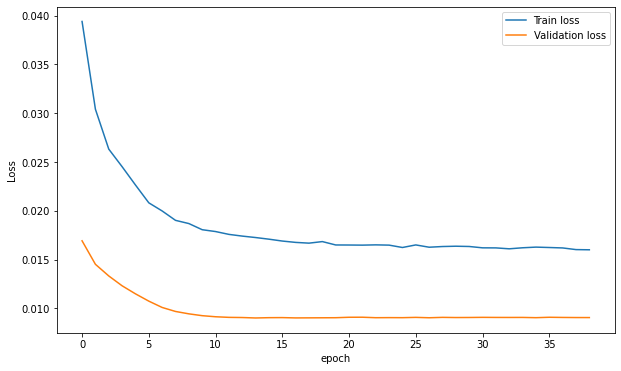

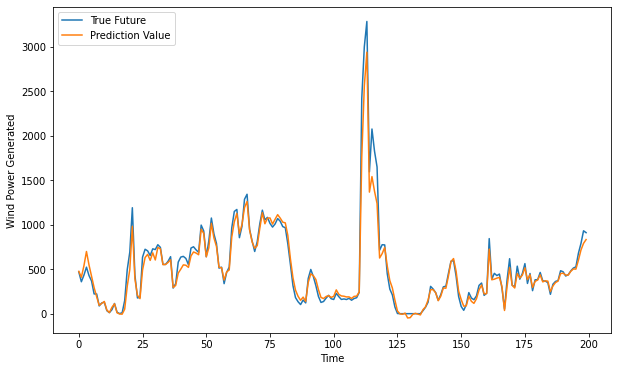

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(12)
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 32, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 16))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model


# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)

def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)
# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM')

### **32-8**

Dimension of train data:  (35371, 4)
Dimension of test data:  (15159, 4)
(35371, 3)
(35371, 1)
(15159, 3)
(15159, 1)
X_train.shape:  (35362, 10, 3)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 3)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 32)            4608      
_________________________________________________________________
dropout (Dropout)            (None, 10, 32)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 8)                 1312      
_________________________________________________________________
dropout_1 (Dropout)          (None, 8)                 0         
_________________________________________________________________
dense (Dense)                (None, 1)                 9         
Total params: 5,929
Tra

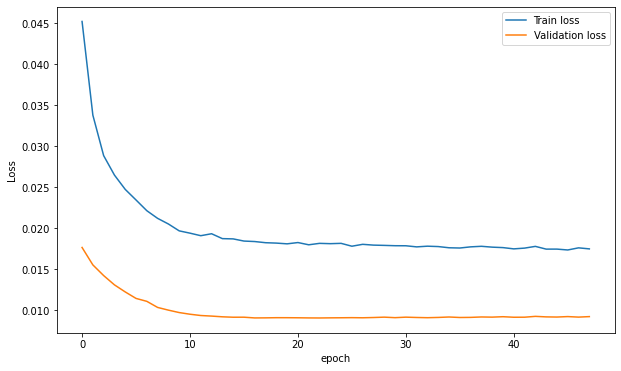

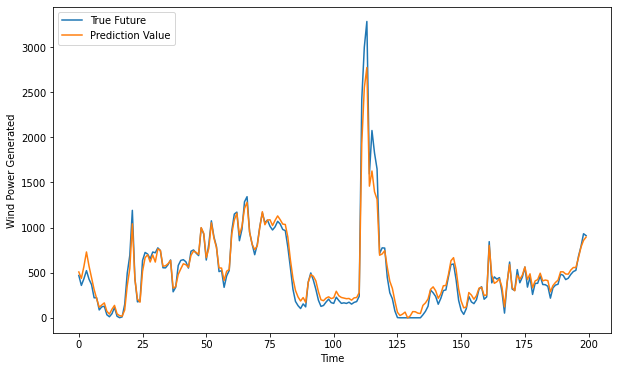

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(1245)

df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)

print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 32, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 8, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 8))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model


# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  #history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)

def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)



# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM')

### **32-4**

Dimension of train data:  (35371, 4)
Dimension of test data:  (15159, 4)
(35371, 3)
(35371, 1)
(15159, 3)
(15159, 1)
X_train.shape:  (35362, 10, 3)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 3)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 32)            4608      
_________________________________________________________________
dropout (Dropout)            (None, 10, 32)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 4)                 592       
_________________________________________________________________
dropout_1 (Dropout)          (None, 4)                 0         
_________________________________________________________________
dense (Dense)                (None, 1)                 5         
Total params: 5,205
Tra

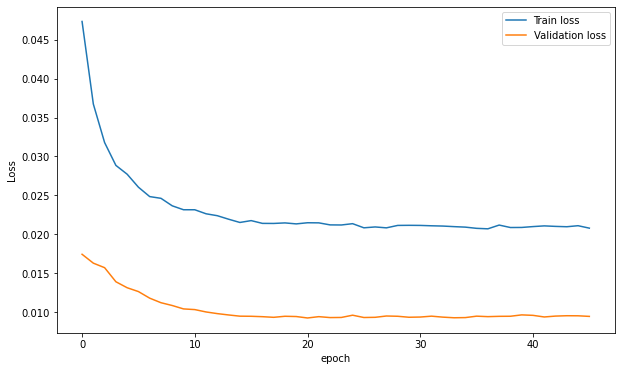

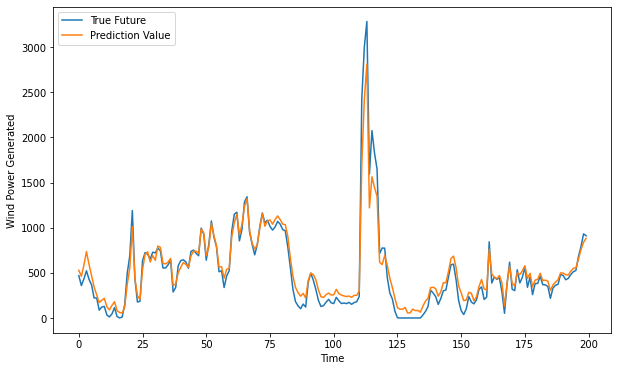

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(1245)

df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)

print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 32, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 8, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 4))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model


# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  #history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)

def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)



# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM')

### **16-16**

Dimension of train data:  (35371, 3)
Dimension of test data:  (15159, 3)
(35371, 2)
(35371, 1)
(15159, 2)
(15159, 1)
X_train.shape:  (35362, 10, 2)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 2)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 16)            1216      
_________________________________________________________________
dropout (Dropout)            (None, 10, 16)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 16)                2112      
_________________________________________________________________
dropout_1 (Dropout)          (None, 16)                0         
_________________________________________________________________
dense (Dense)                (None, 1)                 17        
Total params: 3,345
Tra

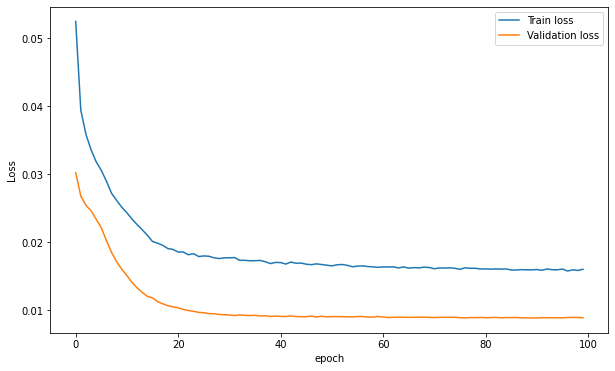

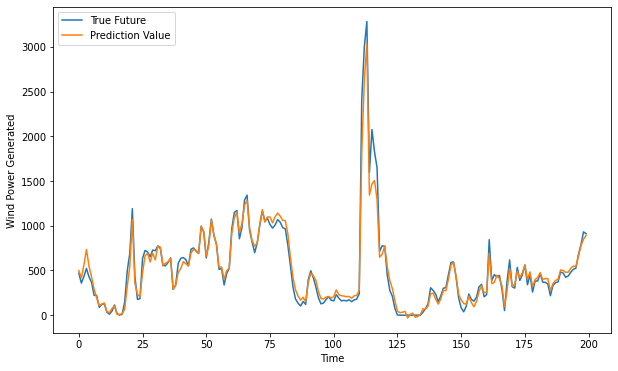

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(145)
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)
df.drop(['Theoretical_Power_Curve (KWh)'], axis=1,inplace=True)
# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 16))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model

# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  #history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)


def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)
# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM 3 LAYERS')

### **16-8**

Dimension of train data:  (35371, 4)
Dimension of test data:  (15159, 4)
(35371, 3)
(35371, 1)
(15159, 3)
(15159, 1)
X_train.shape:  (35362, 10, 3)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 3)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 16)            1280      
_________________________________________________________________
dropout (Dropout)            (None, 10, 16)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 8)                 800       
_________________________________________________________________
dropout_1 (Dropout)          (None, 8)                 0         
_________________________________________________________________
dense (Dense)                (None, 1)                 9         
Total params: 2,089
Tra

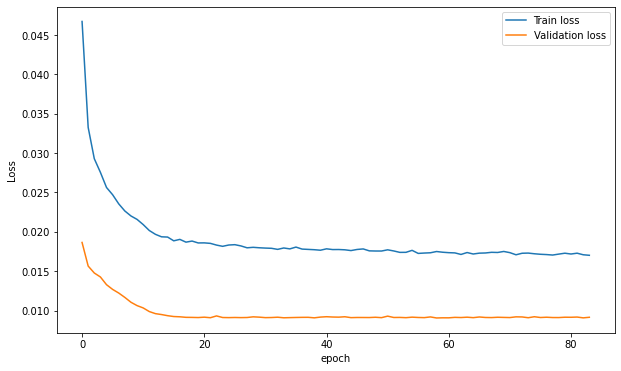

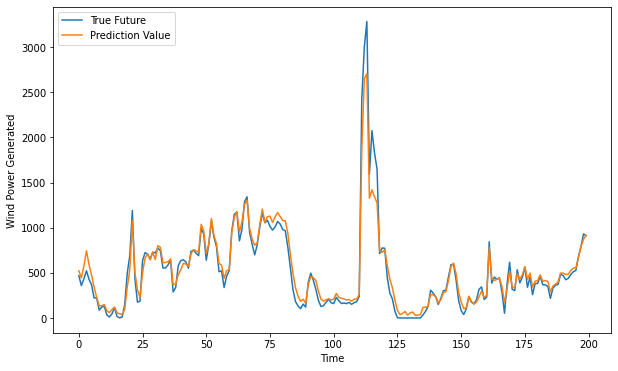

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(1111)
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)
# Create stacked LSTM
# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 8, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 8))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model

# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)

def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)
# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM')

### **16-4**

Dimension of train data:  (35371, 4)
Dimension of test data:  (15159, 4)
(35371, 3)
(35371, 1)
(15159, 3)
(15159, 1)
X_train.shape:  (35362, 10, 3)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 3)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 16)            1280      
_________________________________________________________________
dropout (Dropout)            (None, 10, 16)            0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 4)                 336       
_________________________________________________________________
dropout_1 (Dropout)          (None, 4)                 0         
_________________________________________________________________
dense (Dense)                (None, 1)                 5         
Total params: 1,621
Tra

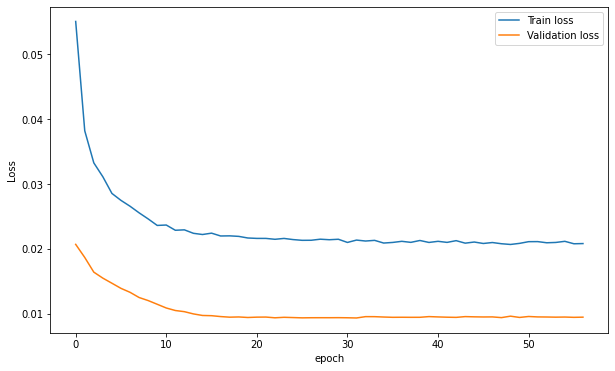

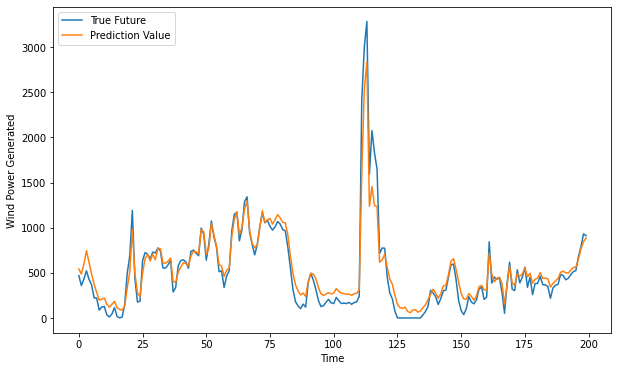

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(555)

df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 4, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 4))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model

# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  #history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)


def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)
# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM 3 LAYERS')

### **8-8**

Dimension of train data:  (35371, 3)
Dimension of test data:  (15159, 3)
(35371, 2)
(35371, 1)
(15159, 2)
(15159, 1)
X_train.shape:  (35362, 10, 2)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 2)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 8)             352       
_________________________________________________________________
dropout (Dropout)            (None, 10, 8)             0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 8)                 544       
_________________________________________________________________
dropout_1 (Dropout)          (None, 8)                 0         
_________________________________________________________________
dense (Dense)                (None, 1)                 9         
Total params: 905
Train

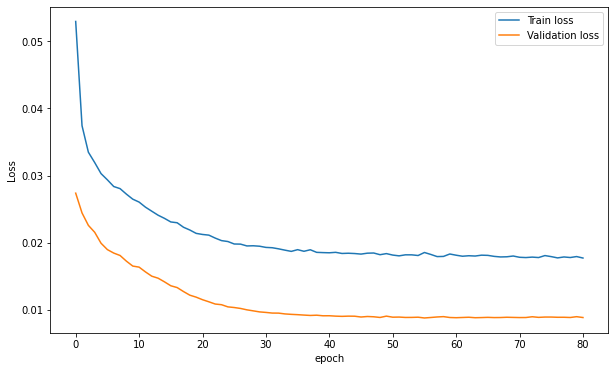

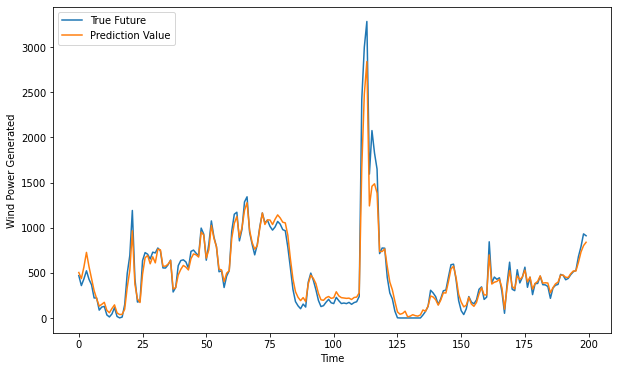

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(333)
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)
df.drop(['Theoretical_Power_Curve (KWh)'], axis=1,inplace=True)
# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)
# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 8, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 8, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 8))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model

# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  #history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)

# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM')

def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(123)
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 8, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 32, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 4))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model

# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)
#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)

def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)
# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM')

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(145)
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  model.add(m (units = 16, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  model.add(m (units = 4))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model

# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  #history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)


def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  #plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)
# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM 3 LAYERS')

### **8-4**

Dimension of train data:  (35371, 4)
Dimension of test data:  (15159, 4)
(35371, 3)
(35371, 1)
(15159, 3)
(15159, 1)
X_train.shape:  (35362, 10, 3)
y_train.shape:  (35362, 1)
X_test.shape:  (15150, 10, 3)
y_test.shape:  (15150, 1)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 8)             384       
_________________________________________________________________
dropout (Dropout)            (None, 10, 8)             0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 4)                 208       
_________________________________________________________________
dropout_1 (Dropout)          (None, 4)                 0         
_________________________________________________________________
dense (Dense)                (None, 1)                 5         
Total params: 597
Train

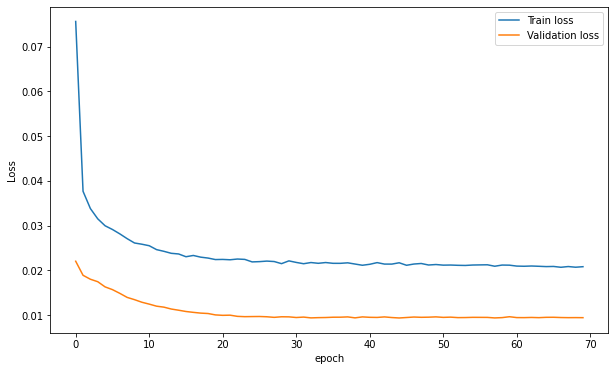

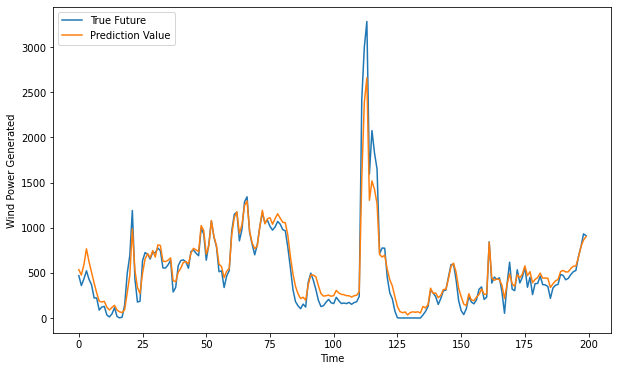

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(333)
df = pd.read_csv('T.csv',index_col=0,parse_dates=True)
df.fillna(df.mean(), inplace=True)
#df.dropna(inplace=True)
df.isnull().sum(axis = 0)
#df.drop(['DewPointC', 'tempC'], axis=1,inplace=True)
#df.isnull().sum(axis = 0)

# Split train data and test data
train_size = int(len(df)*0.7)
train_dataset, test_dataset = df.iloc[:train_size],df.iloc[train_size:]
# Plot train and test data
#plt.figure(figsize = (10, 6))
#plt.plot(train_dataset.Energy)
#plt.plot(test_dataset.Energy)
#plt.xlabel('Time (day)')
#plt.ylabel('Daily water consumption ($m^3$/capita.day)')
#plt.legend(['Train set', 'Test set'], loc='upper right')
print('Dimension of train data: ',train_dataset.shape)
print('Dimension of test data: ', test_dataset.shape)

# Split train data to X and y
X_train = train_dataset.drop('LV ActivePower (kW)', axis = 1)
y_train = train_dataset.loc[:,['LV ActivePower (kW)']]
# Split test data to X and y
X_test = test_dataset.drop('LV ActivePower (kW)', axis = 1)
y_test = test_dataset.loc[:,['LV ActivePower (kW)']]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

# Different scaler for input and output
scaler_x = MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))
# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train)

# Apply the scaler to training data
train_y_norm = output_scaler.transform(y_train)
train_x_norm = input_scaler.transform(X_train)
# Apply the scaler to test data
test_y_norm = output_scaler.transform(y_test)
test_x_norm = input_scaler.transform(X_test)

# Create a 3D input
def create_dataset (X, y, time_steps = 1):
  Xs, ys = [], []
  for i in range(len(X)-time_steps+1):
    v = X[i:i+time_steps, :]
    Xs.append(v)
    ys.append(y[i+time_steps-1])
  return np.array(Xs), np.array(ys)

TIME_STEPS = 10
X_test, y_test = create_dataset(test_x_norm, test_y_norm,TIME_STEPS)
X_train, y_train = create_dataset(train_x_norm, train_y_norm,TIME_STEPS)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)
# Create stacked LSTM
def create_model(m):
  model = Sequential()
  model.add(m (units = 8, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  model.add(Dropout(0.2))
  #model.add(m (units = 4, return_sequences = True,input_shape = [X_train.shape[1], X_train.shape[2]]))
  #model.add(Dropout(0.2))
  model.add(m (units = 4))
  model.add(Dropout(0.2))
  model.add(Dense(1,activation='linear'))
  #Compile model
  opt = tf.keras.optimizers.Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-8)
  model.compile(loss='mse', optimizer=opt)
  return model

# Stacked LSTM
model_SLSTM = create_model(LSTM)
model_SLSTM.summary()

# Fit Stacked LSTM
def fit_model(model):
  early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss',patience = 25)
  history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  #history = model.fit(X_train, y_train, epochs = 100,validation_data=(X_test,y_test), batch_size = 64,shuffle = False, callbacks = [early_stop])
  return history

history_SLSTM = fit_model(model_SLSTM)

# Plot train loss and validation loss
def plot_loss (history):
  plt.figure(figsize = (10, 6))
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.ylabel('Loss')
  plt.xlabel('epoch')
  plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_SLSTM)

#Inverse  tr ans f orm  the  target  v ari able
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

# Make prediction
def prediction(model):
  prediction = model.predict(X_test)
  prediction = scaler_y.inverse_transform(prediction)
  return prediction
prediction_SLSTM = prediction(model_SLSTM)

# Define a function to calculate MAE and RMSE
from sklearn.metrics import mean_absolute_error
def evaluate_prediction(predictions, actual, model_name):
  errors = predictions - actual
  mse = np.square(errors).mean()
  rmse = np.sqrt(mse)
  mae = np.abs(errors).mean()
  print(model_name + ':')
  print('Mean Absolute Error: {:.2f}'.format(mae))
  print('Root Mean Square Error: {:.2f}'.format(rmse))
  print('')

evaluate_prediction(prediction_SLSTM, y_test, 'Stacked LSTM')

def plot_future(prediction, y_test):
  plt.figure(figsize=(10, 6))
  #range_future = len(prediction)
  range_future =200
  yt=np.array(y_test)
  pd=np.array(prediction_SLSTM)
  plt.plot(np.arange(range_future), yt[0:200],label='True Future')
  plt.plot(np.arange(range_future),pd[0:200],label='Prediction Value')
  plt.legend(loc='upper left')
  plt.xlabel('Time')
  plt.ylabel('Wind Power Generated')
  plt.savefig('LSTM.png', dpi=200, bbox_inches='tight')

plot_future(prediction_SLSTM, y_test)